# Building a CNN to Classify Lightning Images

## Introduction
In this lesson, we will build a Convolutional Neural Network (CNN) using Keras to classify images of lightning and rainbows. We will start by preprocessing the images, followed by building, training, and evaluating the CNN. The dataset consists of images from two directories: one containing images of lightning and the other containing images of rainbows.

## Group Discussion Question
Why are CNNs particularly effective for image classification tasks? 

How do the different layers in a CNN contribute to its ability to learn and recognize patterns in images?

## Loading and Preprocessing Images

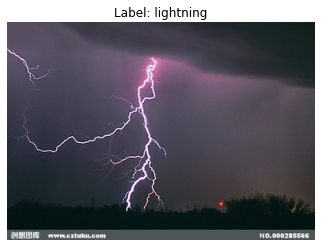

In [10]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Define the directories containing images
lightning_directory = '/Users/romanpaolucci/Desktop/Saddle River Day/Courses (current)/Artificial Intelligence/Course Materials/Unit 3 - Computer Vision/3.3 Convolutional Neural Networks/dataset/lightning'
rainbow_directory = '/Users/romanpaolucci/Desktop/Saddle River Day/Courses (current)/Artificial Intelligence/Course Materials/Unit 3 - Computer Vision/3.3 Convolutional Neural Networks/dataset/rainbow'

# Initialize lists to store images and labels
images = []
labels = []

# Function to load images from a directory
def load_images_from_directory(directory, label):
    for filename in os.listdir(directory):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            img_path = os.path.join(directory, filename)
            img = Image.open(img_path)
            if img.mode != 'RGB':
                img = img.convert('RGB')
            images.append(img)
            labels.append(label)

# Load images and labels from both directories
load_images_from_directory(lightning_directory, 'lightning')
load_images_from_directory(rainbow_directory, 'rainbow')

# Display the first image and its label
plt.imshow(images[0])
plt.title(f'Label: {labels[0]}')
plt.axis('off')
plt.show()

### Normalizing Image Shapes

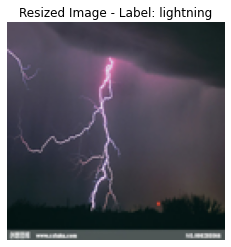

In [11]:
# Define the target size for normalization
target_size = (128, 128)

# Function to resize images
def resize_images(images, target_size):
    resized_images = []
    for img in images:
        resized_img = img.resize(target_size)
        resized_images.append(resized_img)
    return resized_images

# Resize images
resized_images = resize_images(images, target_size)

# Display the first resized image
plt.imshow(resized_images[0])
plt.title(f'Resized Image - Label: {labels[0]}')
plt.axis('off')
plt.show()


### Images to Numpy Arrays

In [12]:
# Function to convert images to numpy arrays
def images_to_numpy(images):
    image_arrays = []
    for img in images:
        img_array = np.array(img)
        image_arrays.append(img_array)
    return np.array(image_arrays)

# Convert resized images to numpy arrays
image_data = images_to_numpy(resized_images)

# Normalize pixel values to [0, 1]
image_data = image_data / 255.0

# Display the shape of the numpy array
print(f'Shape of image data: {image_data.shape}')

Shape of image data: (609, 128, 128, 3)


### Encoding Labels

In [13]:
# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
one_hot_labels = to_categorical(encoded_labels)

# Display the first label and its one-hot encoded format
print(f'Label: {labels[0]}, Encoded: {encoded_labels[0]}, One-hot: {one_hot_labels[0]}')

Label: lightning, Encoded: 0, One-hot: [1. 0.]


### Training and Testing Splits

In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(image_data, one_hot_labels, test_size=0.2, random_state=42)

# Display the shape of the training and testing sets
print(f'Training set shape: {X_train.shape}, {y_train.shape}')
print(f'Testing set shape: {X_test.shape}, {y_test.shape}')

Training set shape: (487, 128, 128, 3), (487, 2)
Testing set shape: (122, 128, 128, 3), (122, 2)


### Building the CNN

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

2024-06-08 19:24:01.735571: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Training the CNN

Epoch 1/10
16/16 [==============================] - 9s 457ms/step - loss: 0.6005 - accuracy: 0.6776 - val_loss: 0.3229 - val_accuracy: 0.8852
Epoch 2/10
16/16 [==============================] - 7s 431ms/step - loss: 0.3747 - accuracy: 0.8337 - val_loss: 0.2453 - val_accuracy: 0.8934
Epoch 3/10
16/16 [==============================] - 7s 441ms/step - loss: 0.3251 - accuracy: 0.8583 - val_loss: 0.3200 - val_accuracy: 0.8689
Epoch 4/10
16/16 [==============================] - 7s 447ms/step - loss: 0.2535 - accuracy: 0.8768 - val_loss: 0.0934 - val_accuracy: 0.9672
Epoch 5/10
16/16 [==============================] - 7s 439ms/step - loss: 0.2983 - accuracy: 0.8706 - val_loss: 0.2284 - val_accuracy: 0.9180
Epoch 6/10
16/16 [==============================] - 7s 432ms/step - loss: 0.2335 - accuracy: 0.8953 - val_loss: 0.1732 - val_accuracy: 0.9262
Epoch 7/10
16/16 [==============================] - 7s 447ms/step - loss: 0.1758 - accuracy: 0.9322 - val_loss: 0.1267 - val_accuracy: 0.9590
Epoch 

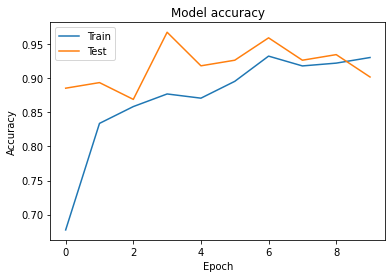

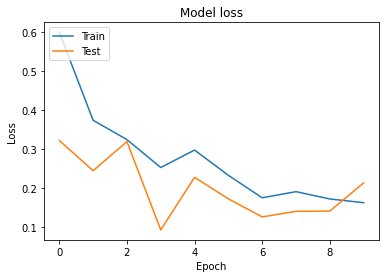

In [16]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Model Evaluation

In [17]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_accuracy:.4f}')

4/4 [==============================] - 0s 112ms/step - loss: 0.2140 - accuracy: 0.9016
Test accuracy: 0.9016


### Practice Problems

1. Modify the CNN architecture to include additional convolutional and pooling layers. Train the modified model and compare its performance with the original model.

2. Implement data augmentation techniques (e.g., rotation, flipping, zooming) to increase the diversity of the training dataset. Train the CNN with the augmented dataset and evaluate its performance.

3. Write a function to save the trained model and load it later for inference. Test the function by saving the model, loading it, and using it to classify new images.

4. Extend the preprocessing pipeline to handle images from more than two classes. Build and train a CNN to classify images into multiple categories and evaluate its performance.


### Conclusion

In this lesson, we covered the entire process of building a Convolutional Neural Network (CNN) using Keras to classify whether an image contains lightning. 

We started by loading and preprocessing the images, normalizing their sizes, converting them to numpy arrays, and encoding the labels. We then built, trained, and evaluated the CNN. Understanding these steps is crucial for building effective image classification models.
